In [45]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier, BaggingClassifier
from sklearn.pipeline import Pipeline

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
data = pd.read_csv('/content/drive/MyDrive/MU projekat/Modeli/Neuralna mreza/creditscore_dataset.csv')

In [18]:
data['Occupation'] = data['Occupation'].fillna(data['Occupation'].mode()[0])
data['Amount_invested_monthly'] = data['Amount_invested_monthly'].fillna(data['Amount_invested_monthly'].median())

In [19]:
label_encoder = LabelEncoder()
data['Credit_Score'] = label_encoder.fit_transform(data['Credit_Score'])

In [20]:
categorical_columns = ['Month', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']
data = pd.get_dummies(data, columns=categorical_columns, drop_first=True)

In [21]:
X = data.drop(columns=['Credit_Score'])
y = data['Credit_Score']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#AdaBoost

In [37]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("adaboost", AdaBoostClassifier(n_estimators=40, learning_rate=1))
])

In [38]:
adbc = pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

score1 = pipeline.score(X_test, y_test)
print(score1)

0.6359711499390491


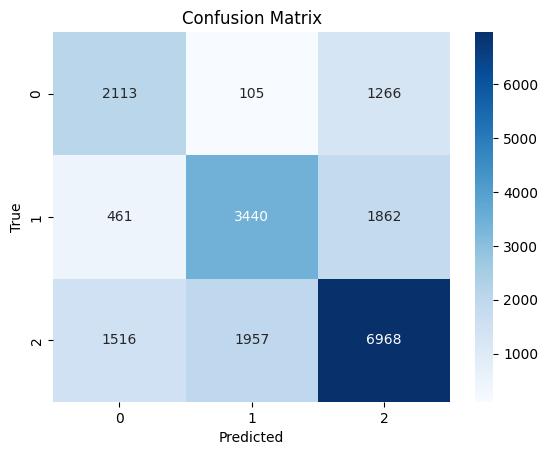

              precision    recall  f1-score   support

           0       0.52      0.61      0.56      3484
           1       0.63      0.60      0.61      5763
           2       0.69      0.67      0.68     10441

    accuracy                           0.64     19688
   macro avg       0.61      0.62      0.62     19688
weighted avg       0.64      0.64      0.64     19688



In [39]:
cm_adbc = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_adbc, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

print(classification_report(y_test, y_pred))

#RandomForest

In [43]:
rfc = RandomForestClassifier(random_state=1234)
rfc.fit(X_train, y_train)

y_pred = rfc.predict(X_test)

cm_rfc = confusion_matrix(y_test, y_pred)
score = rfc.score(X_test, y_test)
print(score)

0.7874339699309224


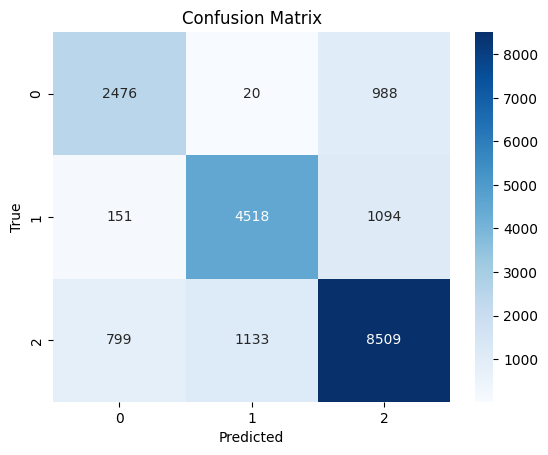

              precision    recall  f1-score   support

           0       0.72      0.71      0.72      3484
           1       0.80      0.78      0.79      5763
           2       0.80      0.81      0.81     10441

    accuracy                           0.79     19688
   macro avg       0.77      0.77      0.77     19688
weighted avg       0.79      0.79      0.79     19688



In [44]:
cm_rfc = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_rfc, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

print(classification_report(y_test, y_pred))

#Bagging

In [52]:
base_rf = RandomForestClassifier(random_state=1234)

pipeline_bagging = Pipeline([
    ("bagging", BaggingClassifier(base_rf, n_estimators=10, random_state=1234))
])

pipeline_bagging.fit(X_train, y_train)

y_pred = pipeline_bagging.predict(X_test)

In [53]:
score_bagging = pipeline_bagging.score(X_test, y_test)
print(score_bagging)

0.7760056887444129


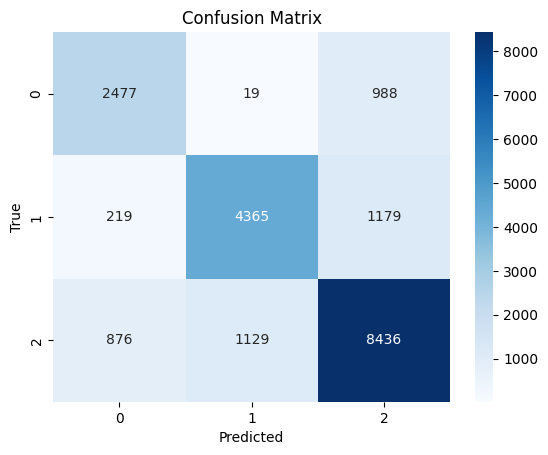

              precision    recall  f1-score   support

           0       0.69      0.71      0.70      3484
           1       0.79      0.76      0.77      5763
           2       0.80      0.81      0.80     10441

    accuracy                           0.78     19688
   macro avg       0.76      0.76      0.76     19688
weighted avg       0.78      0.78      0.78     19688



In [54]:
cm_bagging = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_bagging, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

print(classification_report(y_test, y_pred))